In [1]:
import os
from typing import TypedDict, Annotated, Optional, Literal
from operator import add
from dotenv import load_dotenv

load_dotenv()

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

llm = ChatOpenAI(model="gpt-4o-mini")

In [2]:
class AdaptiveState(TypedDict):
    query: str
    route: str
    documents: Annotated[list[str], add]
    web_results: Annotated[list[str], add]
    sub_queries: Annotated[list[str], add]
    retrieved: Annotated[list[str], add]
    hop_count: int
    max_hops: int
    answer: str

def init_state(q: str, max_hops: int = 3) -> dict:
    return {"query": q, "route": "", "documents": [], "web_results": [],
            "sub_queries": [], "retrieved": [], "hop_count": 0,
            "max_hops": max_hops, "answer": ""}


In [3]:
class _Route(BaseModel):
    """쿼리를 처리 경로로 분류."""
    route: Literal["direct", "rag", "web", "multihop"] = Field(
        description="direct=상식, rag=사내문서, web=최신정보, multihop=복합추론"
    )

router_llm = llm.with_structured_output(_Route)

def classify_node(state: AdaptiveState) -> dict:
    sys = ("질문을 분류하세요. direct=LLM 상식, rag=사내 문서, "
           "web=최신/실시간, multihop=여러 단계 추론이 필요한 복합 질문.")
    r = router_llm.invoke([SystemMessage(content=sys),
                            HumanMessage(content=state["query"])])
    return {"route": r.route}

In [4]:
builder = StateGraph(AdaptiveState)
builder.add_node("classify", classify_node)
builder.add_edge(START, "classify")
builder.add_edge("classify", END)
app_v2 = builder.compile()

queries = [
    "파이썬 리스트가 뭐야?",
    "우리 회사 휴가 정책은?",
    "오늘 코스피 지수는?",
    "봉준호 2019년 영화의 음악감독 출생연도는?",
]
for q in queries:
    r = app_v2.invoke(init_state(q))
    print(f"{q[:25]:<25} → route={r['route']}")

/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=_Route(route='direct'), input_type=_Route])
  return self.__pydantic_serializer__.to_python(


파이썬 리스트가 뭐야?              → route=direct


/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=_Route(route='rag'), input_type=_Route])
  return self.__pydantic_serializer__.to_python(


우리 회사 휴가 정책은?             → route=rag


/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=_Route(route='web'), input_type=_Route])
  return self.__pydantic_serializer__.to_python(


오늘 코스피 지수는?               → route=web
봉준호 2019년 영화의 음악감독 출생연도는? → route=direct


In [5]:
def direct_node(state: AdaptiveState) -> dict:
    r = llm.invoke([
        SystemMessage(content="간결히 답변하세요."),
        HumanMessage(content=state["query"]),
    ])
    return {"answer": r.content}

def route_fn(state: AdaptiveState) -> str:
    return state["route"]

In [6]:
builder = StateGraph(AdaptiveState)
builder.add_node("classify", classify_node)
builder.add_node("direct", direct_node)
builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route_fn, {
    "direct": "direct",
    "rag": END,       # 아직 미구현
    "web": END,
    "multihop": END,
})
builder.add_edge("direct", END)
app_v3 = builder.compile()

# direct로 분류될 쿼리만 진짜로 답함
r = app_v3.invoke(init_state("파이썬 리스트가 뭐야?"))
print(f"route={r['route']}\nanswer={r['answer'][:80]}")

route=direct
answer=파이썬 리스트는 여러 값을 순서대로 저장할 수 있는 데이터 구조로, 대괄호 `[]`로 정의하며, 각 요소는 콤마로 구분합니다. 예를 들어, `m


In [7]:
DOCS = [
    "휴가 정책: 입사 1년 미만은 월 1일, 1년 이상은 연 15일 유급 휴가가 부여됩니다.",
    "출장 규정: 국내 출장은 일비 5만원, 해외는 일비 10만원이 지급됩니다.",
    "재택근무: 주 2일까지 재택근무 가능. 팀장 사전 승인 필요.",
    "야근 식대: 오후 8시 이후 야근 시 1만원 식대 지급.",
    "교육비 지원: 직무 관련 도서/강의 연 30만원 한도 지원.",
    "건강검진: 매년 1회 종합검진 무료 제공.",
    "복장 규정: 비즈니스 캐주얼. 고객 미팅 시 정장 권장.",
]


In [8]:
docs = [Document(page_content=d) for d in DOCS]
vstore = FAISS.from_documents(docs, OpenAIEmbeddings())
retriever = vstore.as_retriever(search_kwargs={'k' : 2})

In [9]:
len(docs)

7

In [10]:
# rag_node가 검색된 문서의 개수를 print 로그로 남기게 수정을 해주세요

In [46]:
def rag_node(state: AdaptiveState) -> dict:
    hits = retriever.invoke(state['query'])
    ctx = '\n'.join(h.page_content for h in hits)
    print(f" [RAG] retrieved {len(hits)} docs")
    r = llm.invoke([
        SystemMessage(content = f'다음 사내 문서 근거로 답변해주세요:\n{ctx}'),
        HumanMessage(content = state['query'])
    ])
    return {
        'documents' : [h.page_content for h in hits],  # document -> documents
        'answer' : '[rag] ' + r.content
    }

In [47]:
builder = StateGraph(AdaptiveState)
builder.add_node("classify", classify_node)
builder.add_node("direct", direct_node)
builder.add_node('rag', rag_node)
builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route_fn, {
    "direct": "direct",
    "rag": 'rag',       
    "web": END,
    "multihop": END,
})
builder.add_edge("direct", END)
builder.add_edge('rag', END)
app_v3 = builder.compile()

r = app_v3.invoke(init_state("우리 회사 휴가 정책은?"))

 [RAG] retrieved 2 docs


In [48]:
r

{'query': '우리 회사 휴가 정책은?',
 'route': 'rag',
 'documents': ['휴가 정책: 입사 1년 미만은 월 1일, 1년 이상은 연 15일 유급 휴가가 부여됩니다.',
  '복장 규정: 비즈니스 캐주얼. 고객 미팅 시 정장 권장.'],
 'web_results': [],
 'sub_queries': [],
 'retrieved': [],
 'hop_count': 0,
 'max_hops': 3,
 'answer': '[rag] 우리 회사의 휴가 정책은 다음과 같습니다: 입사 1년 미만인 직원에게는 매월 1일의 유급 휴가가 부여되며, 입사 1년 이상인 직원에게는 연 15일의 유급 휴가가 주어집니다.'}

In [49]:
r['route']

'rag'

In [50]:
class FakeWebSearch:
    DB = {
        '코스피' : '코스피 지수 : 12345 (전일 대비 +10.0%)',
        '환율' : '원/달러 환율 : 1500원 (전일 대비 1원)',
        '날씨' : '서울 오늘 날씨 : 맑음, 최고 22도'
    }
    def search(self, q:str) -> list[str]:
        hits = [v for k, v in self.DB.items() if k in q]
#         if not hits:
#             return [f"'{q}'에 대한 결과 없음"]
#         return hits[:2]
        return [v for k, v in self.DB.items() if k in q] or [f"'{q}'에 대한 결과 없음"]

In [51]:
web = FakeWebSearch()
web.search('오늘 코스피 어때?')

['코스피 지수 : 12345 (전일 대비 +10.0%)']

In [52]:
def web_node(state: AdaptiveState) -> dict:
    hits = web.search(state['query'])
    ctx = '\n'.join(hits)
    r = llm.invoke([
        SystemMessage(content = f'다음 웹 결과로 답변해주세요:\n{ctx}'),
        HumanMessage(content = state['query'])
    ])
    return {'web_results' : hits, 'answer' : "[web] " + r.content}

In [53]:
# RunnableLambda()

In [54]:
builder = StateGraph(AdaptiveState)
builder.add_node("classify", classify_node)
builder.add_node("direct", direct_node)
builder.add_node('rag', rag_node)
builder.add_node('web', web_node)
builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route_fn, {
    "direct": "direct",
    "rag": 'rag',       
    "web": 'web',
    "multihop": END,
})
builder.add_edge("direct", END)
builder.add_edge('rag', END)
builder.add_edge('web', END)
app_v3 = builder.compile()
# finalize_node -> END
r = app_v3.invoke(init_state("오늘 코스피는?"))

In [55]:
r

{'query': '오늘 코스피는?',
 'route': 'web',
 'documents': [],
 'web_results': ['코스피 지수 : 12345 (전일 대비 +10.0%)'],
 'sub_queries': [],
 'retrieved': [],
 'hop_count': 0,
 'max_hops': 3,
 'answer': '[web] 오늘 코스피 지수는 12345로, 전일 대비 +10.0% 상승했습니다.'}

In [56]:
# fan-in fan-out

In [57]:
# finalize node -> 처리한 timestamp 

In [58]:
from datetime import datetime
def finalize_node(state : AdaptiveState) -> dict:
    route = state['route']
    timestamp = datetime.now().strftime('%H:%M:%S')
    doc_count = len(state['documents']) + len(state['web_results'])
    suffix = f"\n\n[경로 = {route}, 참고문서={doc_count}건, time={timestamp}]"
    return {'answer' : state['answer'] + suffix}

In [59]:
builder = StateGraph(AdaptiveState)
builder.add_node("classify", classify_node)
builder.add_node("direct", direct_node)
builder.add_node('rag', rag_node)
builder.add_node('web', web_node)
builder.add_node('finalize', finalize_node)
builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route_fn, {
    "direct": "direct",
    "rag": 'rag',       
    "web": 'web',
    "multihop": END,
})
builder.add_edge("direct", 'finalize')
builder.add_edge('rag', 'finalize')
builder.add_edge('web', 'finalize')
builder.add_edge('finalize', END)
app_v3 = builder.compile()

In [60]:
for q in ['파이썬 리스트가 뭔가요?', '우리 회사 휴가 정책은 어떻게 되나요?', '오늘 코스피는 얼마인가요?']:
    r = app_v3.invoke(init_state(q))
    print(f"Q : {q}\n {r['answer']}\n")

Q : 파이썬 리스트가 뭔가요?
 파이썬 리스트는 여러 값을 순서대로 저장할 수 있는 자료형으로, 대괄호 `[]`로 정의됩니다. 항목은 서로 다른 데이터 타입을 가질 수 있으며, 인덱스를 사용해 접근할 수 있습니다. 예를 들어, `my_list = [1, 2, 3, "hello"]`와 같이 생성할 수 있습니다. 리스트는 변경 가능(mutable)하여 요소를 추가, 수정, 삭제할 수 있습니다.

[경로 = direct, 참고문서=0건, time=22:44:44]

 [RAG] retrieved 2 docs
Q : 우리 회사 휴가 정책은 어떻게 되나요?
 [rag] 우리 회사의 휴가 정책은 다음과 같습니다:

- 입사 1년 미만: 월 1일의 유급 휴가가 부여됩니다.
- 입사 1년 이상: 연 15일의 유급 휴가가 부여됩니다. 

필요한 점 참고하시기 바랍니다.

[경로 = rag, 참고문서=2건, time=22:44:47]

Q : 오늘 코스피는 얼마인가요?
 [web] 오늘 코스피 지수는 12345입니다. 전일 대비 10.0% 상승했습니다.

[경로 = web, 참고문서=1건, time=22:44:49]



In [61]:
class _Think(BaseModel):
    """다음 행동 결정"""
    next_sub_query : Optional[str] = Field(None, description='더 검색이 필요하면 다음 sub-query, 충분하면 None')
    can_answer : bool = Field(description='현재 정보로 답변 가능한가?')

In [62]:
class AdaptiveState(TypedDict):
    query: str
    route: str
    documents: Annotated[list[str], add]
    web_results: Annotated[list[str], add]
    sub_queries: Annotated[list[str], add]
    retrieved: Annotated[list[str], add]
    hop_count: int
    max_hops: int
    answer: str

In [63]:
# 매 hop마다 reasoning 로그를 누적하도록 think_node를 업데이트

In [64]:
# 새 sub_query 가 기존 sub_query에 있으면 무시하고 -> can_answer = True -> finalize

In [65]:
think_llm = llm.with_structured_output(_Think)

def think_node(state:AdaptiveState) -> dict:
    ctx = '\n'.join(state['retrieved']) or '(아직 없음)'
    sys = (f"원래 질문 : {state['query']}\n수집된 정보:\n{ctx}\n\n"
          "충분하면 can_answer=True, 부족하면 next_sub_query 제시")
    r = think_llm.invoke([SystemMessage(content= sys), HumanMessage(content = '다음 행동?')]) # {'next_sub_query' : ~~~, 'can_answer' : ..}
    hop = state['hop_count'] + 1
    update = {'hop_count': hop}
    
    if r.next_sub_query and r.next_sub_query not in state['sub_queries']:
        update['sub_queries'] = [f"[hop{hop}] r.next_sub_query"]
    else:
        update['answer'] = f"[multihop] (중복/종료) {state['sub_queries']}"
        return update
    if r.can_answer:
        update['answer'] = f"[multihop] 추론 흐름: {state['sub_queries']}"
    return update

In [66]:
think_llm = llm.with_structured_output(_Think)

def think_node(state:AdaptiveState) -> dict:
    ctx = '\n'.join(state['retrieved']) or '(아직 없음)'
    sys = (f"원래 질문 : {state['query']}\n수집된 정보:\n{ctx}\n\n"
          "충분하면 can_answer=True, 부족하면 next_sub_query 제시")
    r = think_llm.invoke([SystemMessage(content= sys), HumanMessage(content = '다음 행동?')])
    hop = state['hop_count'] + 1
    update = {'hop_count': hop}

    if r.next_sub_query and r.next_sub_query not in state['sub_queries']:
        update['sub_queries'] = [f"[hop{hop}] {r.next_sub_query}"]   # 🔧 {} 추가
    else:
        update['answer'] = f"[multihop] (중복/종료) {state['sub_queries']}"
        return update
    if r.can_answer or hop >= state['max_hops']:                     # 🔧 max_hops 조건 추가
        update['answer'] = llm.invoke([                              # 🔧 LLM에 retrieved 넘겨 실답 생성
            SystemMessage(content=f"다음 정보로 답하라:\n{ctx}"),
            HumanMessage(content=state['query']),
        ]).content
    return update


In [67]:
# start - classify - direct   
#                  - rag           - finalize - END
#                   ...

In [68]:
# IRCoT : 중간에 끼어드는 R트리버 CoT
# start - classify - think - sub query O -> retrieve - think ...
#                     |
#                     |--- can answer - answer

In [69]:
# sub_queries : list[str], add

In [74]:
def retrieve_node(state: AdaptiveState) -> dict:
    if not state['sub_queries']:
        return {}
    sub_q = state['sub_queries'][-1]
    hits = retriever.invoke(sub_q)
    return {'retrieved' : [h.page_content for h in hits]}

def think_router(state: AdaptiveState) -> str:
    if state['answer']:
        return 'finalize'
#     if state['hop_count'] >= state['max_hops']:
    if state['hop_count'] >= 5:
        return 'finalize'
    return 'retrieve'

In [75]:
builder = StateGraph(AdaptiveState)
builder.add_node("classify", classify_node)
builder.add_node("direct", direct_node)
builder.add_node('rag', rag_node)
builder.add_node('web', web_node)
builder.add_node('think', think_node)
builder.add_node('retrieve', retrieve_node)
builder.add_node('finalize', finalize_node)

builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route_fn, {
    "direct": "direct",
    "rag": 'rag',       
    "web": 'web',
    "multihop": 'think',
})
builder.add_edge("direct", 'finalize')
builder.add_edge('rag', 'finalize')
builder.add_edge('web', 'finalize')

builder.add_conditional_edges('think', think_router,
                             {'retrieve' : 'retrieve', 'finalize' : 'finalize'})
builder.add_edge('retrieve', 'think')
builder.add_edge('finalize', END)
app_v3 = builder.compile()

In [76]:
# GraphRAG -> db 그래프화

In [77]:
app_v3.invoke(init_state('먼저 건강검진 정보를 알려주고, 그 다음으로 재택근무 정보를 알려줘?'))

/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=_Think(next_sub_query='... 등.', can_answer=True), input_type=_Think])
  return self.__pydantic_serializer__.to_python(


{'query': '먼저 건강검진 정보를 알려주고, 그 다음으로 재택근무 정보를 알려줘?',
 'route': 'multihop',
 'documents': [],
 'web_results': [],
 'sub_queries': ['[hop1] 건강검진 정보에 대한 세부사항이나 특정 내용(예: 검사 종류, 주기, 필요성 등)을 알려주세요.',
  '[hop2] 그 외에 궁금한 부분이 있나요? 예를 들어, 복리후생이나 연봉 관련 정보 등.'],
 'retrieved': ['건강검진: 매년 1회 종합검진 무료 제공.',
  '재택근무: 주 2일까지 재택근무 가능. 팀장 사전 승인 필요.'],
 'hop_count': 2,
 'max_hops': 3,
 'answer': '건강검진 정보는 매년 1회 종합검진이 무료로 제공됩니다.\n\n재택근무 정보로는, 주 2일까지 재택근무가 가능하며, 이 경우 팀장의 사전 승인이 필요합니다.\n\n[경로 = multihop, 참고문서=0건, time=22:46:47]'}

In [39]:
# 그래프 전체 노드 실행 횟수 maximum (50, 100)
# classify 실패 -> fallback (direct)
# web_search / tool : api 실패

In [40]:
# Fail counter 추가

In [41]:
CLASSIFY_COUNTER = {'count':0}

In [42]:
def safe_classify_node(state : AdaptiveState) -> dict:
    try:
        sys = "direct/rag/web/multiphop 중 하나로 분류하세요"
        r = router_llm.invoke([SystemMessage(content = sys), HumanMessage(content=state['query'])])
        return {'route' : r.route}
    except Exception as e:
        CLASSIFY_COUNTER['count'] +=1
        print(f" [Classify 실패 : {CLASSIFY_COUNTER['count']} : {e}] -> fallback : direct")
        return {'route' : 'direct'}
        

In [43]:
builder = StateGraph(AdaptiveState)
builder.add_node("classify", safe_classify_node)
builder.add_node("direct", direct_node)
builder.add_node('rag', rag_node)
builder.add_node('web', web_node)
builder.add_node('think', think_node)
builder.add_node('retrieve', retrieve_node)
builder.add_node('finalize', finalize_node)

builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route_fn, {
    "direct": "direct",
    "rag": 'rag',       
    "web": 'web',
    "multihop": 'think',
})
builder.add_edge("direct", 'finalize')
builder.add_edge('rag', 'finalize')
builder.add_edge('web', 'finalize')

builder.add_conditional_edges('think', think_router,
                             {'retrieve' : 'retrieve', 'finalize' : 'finalize'})
builder.add_edge('retrieve', 'think')
builder.add_edge('finalize', END)
app_v3 = builder.compile()

In [44]:
from IPython.display import Image, display

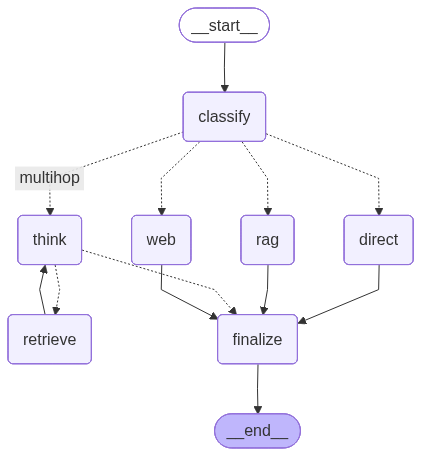

In [45]:
Image(app_v3.get_graph().draw_mermaid_png())